In [1]:
"""
Neural Network + Dropout + Permutation Importance (no plots)
- Reads: /mnt/data/heart_rate_non_linear_features_train.csv
- Target column: 'condition'
- Uses numeric features only (categoricals ignored for stability)
- Outputs:
    - console printout of top features
    - CSV: feature_importance_nn_permutation.csv
"""

# ---------- safety & threads ----------
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"      # force CPU
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

# ---------- imports ----------
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score

import torch
import torch.nn as nn
import torch.nn.functional as F

# ---------- config ----------
CSV_PATH = "/Users/kevincao/Downloads/heart_rate_non_linear_features_train.csv"
TARGET = "condition"
VAL_SIZE = 0.2
BATCH_SIZE = 32
LR = 1e-3
EPOCHS = 100
PATIENCE = 8
DROPOUT_P = 0.3
PERM_REPEATS = 2   

df = pd.read_csv(CSV_PATH)
assert TARGET in df.columns, f"Expected target column '{TARGET}'."

y_raw = df[TARGET].astype(str).values
X_df = df.drop(columns=[TARGET])


num_cols = X_df.select_dtypes(include=[np.number]).columns.tolist()
if not num_cols:
    raise RuntimeError("No numeric features found. Convert categoricals to numeric first.")
X_num = X_df[num_cols].copy()

mask = ~pd.isna(y_raw)
for c in num_cols:
    mask &= ~X_num[c].isna()
X_num = X_num.loc[mask].reset_index(drop=True)
y_raw = y_raw[mask]

# encode target
le = LabelEncoder()
y_all = le.fit_transform(y_raw)
num_classes = len(le.classes_)

# split
X_tr_df, X_va_df, y_tr, y_va = train_test_split(
    X_num, y_all, test_size=VAL_SIZE, random_state=42, stratify=y_all
)

# standardize 
mu = X_tr_df.mean(axis=0).values
sd = X_tr_df.std(axis=0).values
sd[sd == 0] = 1.0

X_tr = ((X_tr_df.values - mu) / sd).astype(np.float32)
X_va = ((X_va_df.values - mu) / sd).astype(np.float32)

y_tr = np.asarray(y_tr)
y_va = np.asarray(y_va)

X_tr_t = torch.from_numpy(X_tr)
X_va_t = torch.from_numpy(X_va)
y_tr_t = torch.from_numpy(y_tr).long()
y_va_t = torch.from_numpy(y_va).long()

# model
class TinyMLP(nn.Module):
    def __init__(self, in_dim, out_classes, p=0.3):
        super().__init__()
        self.fc1 = nn.Linear(in_dim, 64)
        self.fc2 = nn.Linear(64, 32)
        self.drop = nn.Dropout(p)
        self.out = nn.Linear(32, 1 if out_classes == 2 else out_classes)
        self.out_classes = out_classes

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = self.drop(x)
        x = F.relu(self.fc2(x))
        x = self.drop(x)
        if self.out_classes == 2:
            return torch.sigmoid(self.out(x)).squeeze(1)  # shape [N]
        else:
            return self.out(x)  # logits [N, C]

in_dim = X_tr.shape[1]
model = TinyMLP(in_dim, num_classes, p=DROPOUT_P)

opt = torch.optim.Adam(model.parameters(), lr=LR)
crit = nn.BCELoss() if num_classes == 2 else nn.CrossEntropyLoss()

# early stopping
def iterate_minibatches(X, y, batch_size, shuffle=True):
    n = X.shape[0]
    idx = np.arange(n)
    if shuffle:
        np.random.shuffle(idx)
    for i in range(0, n, batch_size):
        sel = idx[i:i+batch_size]
        yield torch.from_numpy(X[sel]), torch.from_numpy(y[sel]).long()

best_acc, wait = 0.0, 0
best_state = {k: v.clone() for k, v in model.state_dict().items()}

for epoch in range(EPOCHS):
    model.train()
    for xb_t, yb_t in iterate_minibatches(X_tr, y_tr, BATCH_SIZE, shuffle=True):
        opt.zero_grad()
        out = model(xb_t)
        loss = crit(out, yb_t.float()) if num_classes == 2 else crit(out, yb_t)
        loss.backward()
        opt.step()

    model.eval()
    with torch.no_grad():
        out = model(X_va_t)
        if num_classes == 2:
            pred = (out > 0.5).int().numpy()
        else:
            pred = out.argmax(1).numpy()
        acc = accuracy_score(y_va, pred)

    if acc > best_acc:
        best_acc = acc
        wait = 0
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
    else:
        wait += 1
        if wait >= PATIENCE:
            break

model.load_state_dict(best_state)
print(f"Validation accuracy (baseline): {best_acc:.4f}")

# permutation
rng = np.random.default_rng(0)

def metric_numpy(Xv_np):
    Xt = torch.from_numpy(Xv_np.astype(np.float32))
    model.eval()
    with torch.no_grad():
        out = model(Xt)
        if num_classes == 2:
            pred = (out > 0.5).int().numpy()
        else:
            pred = out.argmax(1).numpy()
    return accuracy_score(y_va, pred)

baseline = metric_numpy(X_va.copy())
drops = np.zeros(in_dim, dtype=np.float32)
Xv = X_va.copy()

for j in range(in_dim):
    col = Xv[:, j].copy()
    scores = []
    for _ in range(PERM_REPEATS):
        rng.shuffle(Xv[:, j])            # shuffle this column
        scores.append(metric_numpy(Xv))  # evaluate
        Xv[:, j] = col                   # restore
    drops[j] = baseline - float(np.mean(scores))

order = np.argsort(drops)[::-1]
feat_names = np.array(num_cols)

# print top 20
print("\nTop features by permutation importance (drop in validation accuracy):")
for rank, idx in enumerate(order[:20], 1):
    print(f"{rank:>2}. {feat_names[idx]}: {drops[idx]:.6f}")

# save CSV
out_df = pd.DataFrame({
    "feature": feat_names[order],
    "perm_importance_drop_in_accuracy": drops[order]
})
out_df.to_csv("feature_importance_nn_permutation.csv", index=False)
print("\nSaved: feature_importance_nn_permutation.csv")


Validation accuracy (baseline): 0.8055

Top features by permutation importance (drop in validation accuracy):
 1. SD1: 0.249364
 2. higuci: 0.238810
 3. SD2: 0.220294
 4. sampen: 0.153504
 5. datasetId: 0.000000

Saved: feature_importance_nn_permutation.csv


Epoch 01 | train_acc=0.614 | val_acc=0.718
Epoch 02 | train_acc=0.696 | val_acc=0.758
Epoch 04 | train_acc=0.748 | val_acc=0.804
Epoch 06 | train_acc=0.772 | val_acc=0.831
Epoch 08 | train_acc=0.785 | val_acc=0.851
Epoch 10 | train_acc=0.795 | val_acc=0.864
Epoch 12 | train_acc=0.803 | val_acc=0.874
Epoch 14 | train_acc=0.808 | val_acc=0.880
Epoch 16 | train_acc=0.812 | val_acc=0.888
Epoch 18 | train_acc=0.816 | val_acc=0.888
Epoch 20 | train_acc=0.820 | val_acc=0.896
Epoch 22 | train_acc=0.823 | val_acc=0.893
Epoch 24 | train_acc=0.825 | val_acc=0.897
Epoch 26 | train_acc=0.827 | val_acc=0.902
Epoch 28 | train_acc=0.830 | val_acc=0.900
Epoch 30 | train_acc=0.832 | val_acc=0.904
Epoch 32 | train_acc=0.833 | val_acc=0.904
Epoch 34 | train_acc=0.835 | val_acc=0.911
Epoch 36 | train_acc=0.835 | val_acc=0.910
Epoch 38 | train_acc=0.839 | val_acc=0.913
Epoch 40 | train_acc=0.839 | val_acc=0.915
Epoch 42 | train_acc=0.841 | val_acc=0.911
Epoch 44 | train_acc=0.842 | val_acc=0.914
Epoch 46 | 

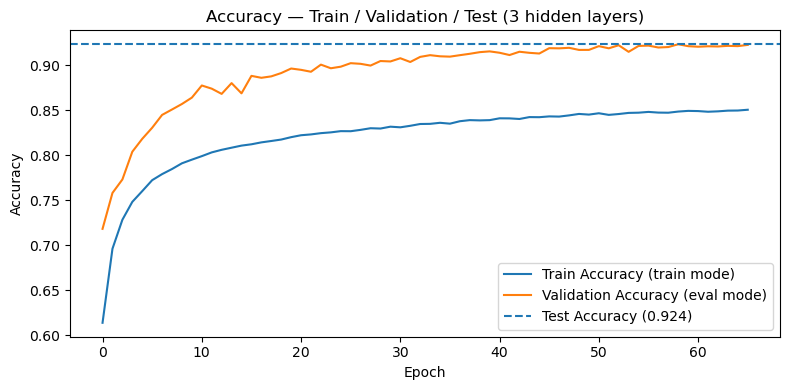


Test ROC-AUC micro: 0.9904 | macro: 0.9931


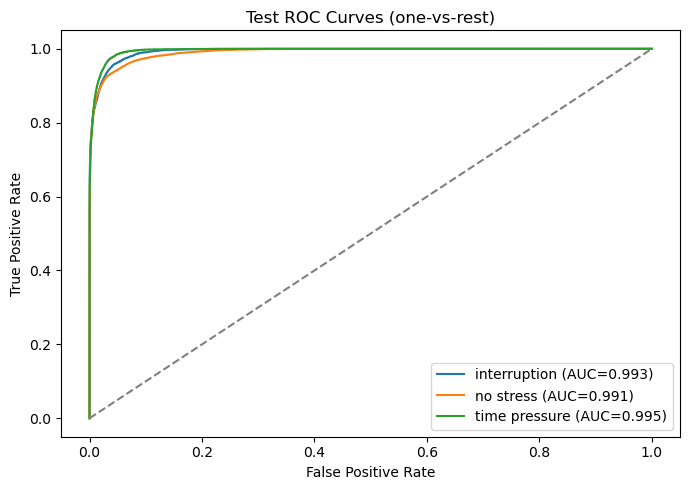

In [7]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.metrics import accuracy_score, f1_score, roc_curve, roc_auc_score, auc
from sklearn.utils.class_weight import compute_class_weight

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

CSV = "/Users/kevincao/Downloads/heart_rate_non_linear_features_train.csv"
BASE_FEATS = ["SD1", "SD2", "higuci", "sampen"]
TARGET = "condition"
SEED = 42

VAL_FRAC = 0.15
TEST_FRAC = 0.15

MAX_EPOCHS = 70
BATCH_SIZE = 128
LR = 1e-3
WD = 2e-4
DROPOUT = 0.2
PATIENCE = 10
CLIP_NORM = 1.0

torch.manual_seed(SEED)
np.random.seed(SEED)

# data
df = pd.read_csv(CSV)
df = df.dropna(subset=BASE_FEATS + [TARGET]).copy()

X_base = df[BASE_FEATS].astype(np.float32).values
y_raw  = df[TARGET].astype(str).values

# Feature engineering from the 4 inputs
SD1, SD2, H, S = [X_base[:, i:i+1] for i in range(4)]
X_eng = np.concatenate(
    [
        X_base,                         # 4
        SD1**2, SD2**2, H**2, S**2,     # +4 = 8
        SD1*SD2, SD1*H, SD1*S,          # +3
        SD2*H, SD2*S, H*S               # +3 = 14
    ],
    axis=1
).astype(np.float32)

# Encode labels
le = LabelEncoder()
y = le.fit_transform(y_raw)
num_classes = len(le.classes_)

# 70/15/15 split
X_train, X_tmp, y_train, y_tmp = train_test_split(
    X_eng, y, test_size=(VAL_FRAC + TEST_FRAC), random_state=SEED, stratify=y
)
rel_test = TEST_FRAC / (VAL_FRAC + TEST_FRAC)
X_val, X_test, y_val, y_test = train_test_split(
    X_tmp, y_tmp, test_size=rel_test, random_state=SEED, stratify=y_tmp
)

# Standardization
mu = X_train.mean(axis=0, dtype=np.float64)
sd = X_train.std(axis=0, dtype=np.float64)
sd[sd == 0] = 1.0

def z(a):
    return ((a - mu) / sd).astype(np.float32)

X_train, X_val, X_test = z(X_train), z(X_val), z(X_test)

# DataLoaders
train_dl = DataLoader(
    TensorDataset(torch.from_numpy(X_train), torch.from_numpy(y_train).long()),
    batch_size=BATCH_SIZE, shuffle=True
)
val_dl   = DataLoader(
    TensorDataset(torch.from_numpy(X_val),   torch.from_numpy(y_val).long()),
    batch_size=BATCH_SIZE, shuffle=False
)
test_dl  = DataLoader(
    TensorDataset(torch.from_numpy(X_test),  torch.from_numpy(y_test).long()),
    batch_size=BATCH_SIZE, shuffle=False
)

# 3 layer model
class BetterMLP_v3(nn.Module):
    def __init__(self, in_dim, out_classes, p=0.2):
        super().__init__()
        self.fc1 = nn.Linear(in_dim, 160)
        self.bn1 = nn.BatchNorm1d(160)
        self.fc2 = nn.Linear(160, 96)
        self.bn2 = nn.BatchNorm1d(96)
        self.fc3 = nn.Linear(96, 64)
        self.bn3 = nn.BatchNorm1d(64)
        self.drop = nn.Dropout(p)
        self.out = nn.Linear(64, out_classes)

    def forward(self, x):
        x = self.bn1(self.fc1(x))
        x = F.gelu(x)
        x = self.drop(x)
        x = self.bn2(self.fc2(x))
        x = F.gelu(x)
        x = self.drop(x)
        x = self.bn3(self.fc3(x))
        x = F.gelu(x)
        x = self.drop(x)
        return self.out(x)   

model = BetterMLP_v3(in_dim=X_train.shape[1], out_classes=num_classes, p=DROPOUT)

opt = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WD)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=MAX_EPOCHS)

# Class weights
classes = np.unique(y_train)
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)
class_weights_t = torch.tensor(class_weights, dtype=torch.float32)
criterion = nn.CrossEntropyLoss(weight=class_weights_t)

def epoch_step(loader, train_mode=True):
    if train_mode:
        model.train()
    else:
        model.eval()
    total_loss, total_correct, total_n = 0.0, 0, 0
    for xb, yb in loader:
        if train_mode:
            opt.zero_grad(set_to_none=True)
        out = model(xb)
        loss = criterion(out, yb)
        if train_mode:
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), CLIP_NORM)
            opt.step()
        with torch.no_grad():
            preds = out.argmax(1)
            total_correct += (preds == yb).sum().item()
        bs = yb.size(0)
        total_loss += loss.item() * bs
        total_n += bs
    return total_loss / total_n, total_correct / total_n

# early stopping
best_val_loss = float("inf")
best_state = None
wait = 0

hist_tr_acc, hist_va_acc = [], []

for epoch in range(1, MAX_EPOCHS + 1):
    tr_loss, tr_acc = epoch_step(train_dl, train_mode=True)
    va_loss, va_acc = epoch_step(val_dl,   train_mode=False)
    scheduler.step()

    hist_tr_acc.append(tr_acc)
    hist_va_acc.append(va_acc)

    # print ONLY accuracies
    if epoch % 2 == 0 or epoch == 1:
        print(
            f"Epoch {epoch:02d} | "
            f"train_acc={tr_acc:.3f} | "
            f"val_acc={va_acc:.3f}"
        )

    # early stopping on val loss
    if va_loss < best_val_loss - 1e-4:
        best_val_loss = va_loss
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        wait = 0
    else:
        wait += 1
        if wait >= PATIENCE:
            print(f"Early stopping at epoch {epoch}")
            break

if best_state is not None:
    model.load_state_dict(best_state)

# Evaluation
def eval_loader(loader, split_name=""):
    model.eval()
    all_y, all_p = [], []
    with torch.no_grad():
        for xb, yb in loader:
            logits = model(xb)
            preds = logits.argmax(1)
            all_y.append(yb.numpy())
            all_p.append(preds.numpy())
    y_true = np.concatenate(all_y)
    y_pred = np.concatenate(all_p)
    acc  = accuracy_score(y_true, y_pred)
    f1_m = f1_score(y_true, y_pred, average="macro")
    f1_w = f1_score(y_true, y_pred, average="weighted")
    print(f"{split_name:<6} Accuracy: {acc:.4f} | F1-macro: {f1_m:.4f} | F1-weighted: {f1_w:.4f}")
    return y_true, y_pred, acc, f1_m, f1_w

print("\nFinal metrics (v3 model: 3 hidden layers)")
y_train_hat, y_train_pred, train_acc, train_f1m, train_f1w = eval_loader(train_dl, "Train")
y_val_hat,   y_val_pred,   val_acc,   val_f1m,   val_f1w   = eval_loader(val_dl,   "Val")
y_test_hat,  y_test_pred,  test_acc,  test_f1m,  test_f1w  = eval_loader(test_dl,  "Test")

# Plot accuracy
plt.figure(figsize=(8,4))
plt.plot(hist_tr_acc, label="Train Accuracy (train mode)")
plt.plot(hist_va_acc, label="Validation Accuracy (eval mode)")
plt.axhline(y=test_acc, linestyle="--", label=f"Test Accuracy ({test_acc:.3f})")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy — Train / Validation / Test (3 hidden layers)")
plt.legend()
plt.tight_layout()
plt.show()

#  ROC curve + AUC 
model.eval()
all_probs = []
all_true  = []
with torch.no_grad():
    for xb, yb in test_dl:
        logits = model(xb)
        probs = F.softmax(logits, dim=1).numpy()  
        all_probs.append(probs)
        all_true.append(yb.numpy())
probs_test = np.concatenate(all_probs)  
y_test_np  = np.concatenate(all_true)   


y_test_bin = label_binarize(y_test_np, classes=np.arange(num_classes))  

plt.figure(figsize=(7,5))

aucs = []
for c in range(num_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, c], probs_test[:, c])
    roc_auc = auc(fpr, tpr)
    aucs.append(roc_auc)
    class_name = le.classes_[c]
    plt.plot(fpr, tpr, label=f"{class_name} (AUC={roc_auc:.3f})")

# AUC
micro_auc = roc_auc_score(y_test_bin, probs_test, average="micro")
macro_auc = roc_auc_score(y_test_bin, probs_test, average="macro")
print(f"\nTest ROC-AUC micro: {micro_auc:.4f} | macro: {macro_auc:.4f}")

plt.plot([0,1], [0,1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Test ROC Curves (one-vs-rest)")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()
